# Разработка функций расчета лучшего узла полным перебором

In [1]:
import osmnx as ox
import pandas as pd
import geopandas as gpd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from genesis.swiss_knife import MSF
import time
from genesis.tools import Progressbar
from genesis.optimal_service_areas import voronoi_forest, voronoi_forest_for_area
from genesis.estimated_arrival_parameters import nodes_metric, arrival_time

In [2]:
area = gpd.read_file("tests/data/test_polygon.gpkg")
G = ox.load_graphml("tests/data/test_rng.ml")

In [6]:
def best_node_full(G,
                  #  path_function=MSF,
                  #  metric_function=arrival_time(np.mean),
                  #  voronoi_function=voronoi_forest,
                   nodes_list=None,
                   node_calc_end_function=None,
                   **kwargs):
   
   if nodes_list is None:
        nodes_list = G.nodes()
   
   best_metric = None
   best_node = None
   for node in nodes_list:
      node_metric = nodes_metric(G=G,
            sources=[node],
            # path_function=path_function,
            # metric_function=metric_function,
            # voronoi_function=voronoi_function,
            **kwargs)
      # здесь должна быть проверка на корректность охвата графа
      if best_metric is None:
         best_metric = node_metric
         best_node = node
      if best_metric > node_metric:
         best_metric = node_metric
         best_node = node
      if node_calc_end_function:
         node_calc_end_function()
      
   return best_node, best_metric

# =================== Проверка ============================
nodes_list = list(G.nodes())[:100]

pb = Progressbar(len(nodes_list), bins=10)
best_node, best_metric = best_node_full(G=G,
               nodes_list=nodes_list,
               node_calc_end_function=pb,
               metric_function=arrival_time(np.max))
print(best_node, best_metric)

pb = Progressbar(len(nodes_list), bins=10)
best_node, best_metric = best_node_full(G=G,
               nodes_list=nodes_list,
               node_calc_end_function=pb,
               metric_function=arrival_time(np.mean),  # Это можно опустить - в nodes_metric стоит по умолчанию
               )
print(best_node, best_metric)

pb = Progressbar(len(nodes_list), bins=10)
best_node, best_metric = best_node_full(G=G,
               nodes_list=nodes_list,
               node_calc_end_function=pb,
               metric_function=arrival_time(np.median))
print(best_node, best_metric)

|##########| 100.0%
868999919 18.935884857142863
|##########| 100.0%
426923808 8.355415617070701
|##########| 100.0%
1278022171 8.167945857142858


<Axes: >

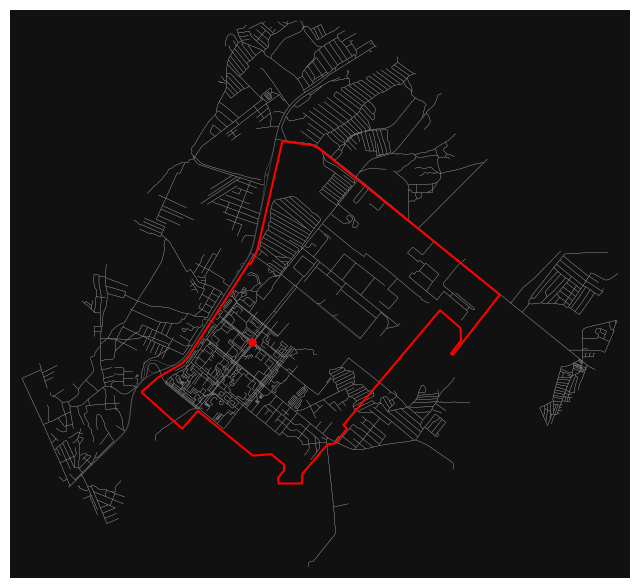

In [8]:
# Печать карты
nodes = ox.graph_to_gdfs(G, edges=False)
# ax = nodes[nodes['nearest'].notna()].plot(markersize=1, column='route_times')
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
area.boundary.plot(ax=ax, color='r')
nodes.loc[[best_node]].plot(ax=ax, markersize=25, color='red')

In [7]:
print('Тест времени расчета лучшего узла с использованием разных функций леса Вороного:')
cnt = 1000
nodes_list = list(G.nodes())[:cnt]
print('Узлов:', cnt)
print('='*80)


nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)
points = nodes[points_mask]
points = list(points.index)


st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest:', round(ft-st,2))
print(best_node, best_metric, '\n')

st = time.time()
pb = Progressbar(len(nodes_list), bins=40)
best_node, best_metric = best_node_full(G=G,
               voronoi_function=voronoi_forest_for_area,
               area=area,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_area:', round(ft-st,2))
print(best_node, best_metric, '\n')

st = time.time()
pb = Progressbar(len(nodes_list), bins=40, ok_char='>', est_char=' ')
best_node, best_metric = best_node_full(G=G,
               nodes_mask=points_mask,
               nodes_list=nodes_list,
               node_calc_end_function=pb)
ft = time.time()
print('best_node_full + voronoi_forest_for_points_mask:', round(ft-st,2))
print(best_node, best_metric, '\n')

best_node, best_metric

Тест времени расчета лучшего узла с использованием разных функций леса Вороного:
Узлов: 100
|########################################| 100.0%
best_node_full + voronoi_forest: 6.24
426923808 8.355415617070701 

|########################################| 100.0%
best_node_full + voronoi_forest_for_area: 33.63
426923837 4.361576450827 

|>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>| 100.0%
best_node_full + voronoi_forest_for_points_mask: 6.18
426923837 4.361576450827 



(426923837, 4.361576450827)